# Real-Rate-Regime — quantitative teardown
### Shiller long rate · 150 years · level sort · momentum sort · timing overlay · HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Don't_fight_the_Fed%3F: Backfires](https://img.shields.io/badge/Don't_fight_the_Fed%3F-Backfires-8b949e?style=flat-square)

The quant companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether the Shiller real long rate (nominal long rate − trailing CPI inflation) level or 12-month change predicts the forward 12-month real S&P return, and whether a mechanical timing overlay beats buy-and-hold.

> ⚠️ **Not investment advice.** Real data: Shiller monthly S&P 500 dataset (staged parquet), 1873-01–2023-09, fingerprint `08e8d2f5f488`. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **`💡 In plain words`** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from real_rate_regime import data, strategy as st

# Try to load real Shiller data (pre-staged parquet)
try:
    df_real = data.fetch_shiller(start_year=1873)
    df_real["monthly_real_ret"] = np.log(df_real["sp500_real"] / df_real["sp500_real"].shift(1))
    HAVE_REAL = True
except FileNotFoundError:
    df_real = None
    HAVE_REAL = False

print("real Shiller data present:", HAVE_REAL)

R = dict(
    n=1797,
    date_start="1873-01", date_end="2023-09", fingerprint="08e8d2f5f488",
    q1_rr=-3.0, q1_fwd=-0.6, q1_t=-0.32,
    q2_rr=1.2, q2_fwd=4.4, q2_t=2.91,
    q3_rr=3.2, q3_fwd=5.0, q3_t=3.14,
    q4_rr=8.2, q4_fwd=7.9, q4_t=3.65,
    rising_fwd=6.4, rising_t=4.55, rising_n=846,
    falling_fwd=2.1, falling_t=1.58, falling_n=951,
    corr_level=0.149, corr_chg=0.092,
    strat_ann=-0.2, strat_sharpe=-0.017, strat_t=-0.17,
    bh_ann=2.4, bh_sharpe=0.169, bh_t=1.67,
    diff_t=-2.74, frac_in=52.5,
)

from quantlab import analytics, stats


real Shiller data present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Corr(real rate level, fwd12) = **+0.149**; corr(12m chg, fwd12) = **+0.092** — *positive*, opposite to the claim. Q4 (highest rates) leads with **+7.9%** fwd return; Q1 (lowest) returns **-0.6%**. |
| **Tradability** | `MIRAGE` | Timing strategy: **-0.2%/yr** (HAC *t* = -0.17) vs BaH **+2.4%/yr** (*t* = +1.67); diff *t* = **-2.74**. Underperforms before costs. |
| **Don't fight the Fed?** | `BACKFIRES` | Rising-rate months: **+6.4%/yr** (*t* = +4.55); falling: **+2.1%/yr** (*t* = +1.58). The rule exits during the *good* regime. |

> 💡 Three tests, one economic explanation: rising real rates often signal economic expansion, when both rates and equities rise together. Negative real rates signal crises, not buying opportunities.

## 1 · The claim, steelmanned

Let $r_t$ = Shiller nominal long rate / 100 − CPI trailing inflation = real long rate. Let $R^{\text{fwd}}_{t,12}$ = forward 12-month real S&P price return starting at $t+1$. The claim asserts two hypotheses:

- **H₁ (level).** $\mathbb{E}[R^{\text{fwd}}_{t,12}]$ is monotone *decreasing* in $r_t$: high real rates → low forward equity returns (the discount-rate channel).
- **H₂ (momentum).** $\mathbb{E}[R^{\text{fwd}}_{t,12}]$ is *lower* when $\Delta_{12}r_t > 0$ (rates rising): the tightening-headwind channel.

A mechanical corollary: a regime-timing rule that goes risk-off during H₂ periods should beat buy-and-hold. We test all three on Shiller monthly data, 1873–2023.

## 2 · So what?

The discount-rate channel is theoretically sound: the Gordon Growth Model gives $P = D/(k - g)$, so a rise in the real component of $k$ must lower $P/D$ and thus expected returns. The interesting failure is *empirical*: the confound is that rising real rates often accompany *rising g* (strong real growth), which swamps the discount-rate effect. Testing it formally, on the full history, is the only way to see which channel dominates.

## 3 · Protocol

- **Signal.** Real long rate = Shiller 'Long Interest Rate' / 100 − trailing 12m CPI inflation. 12m change: $\Delta_{12}r_t = r_t - r_{t-12}$.
- **Target.** Forward 12-month real S&P return from Shiller's real price index (price only, no dividends — a conservative lower bound that avoids reinvestment assumptions).
- **Tests.** (1) Quartile level sort; (2) rising/falling momentum sort; (3) monthly timing overlay with lag = 1 (signal at *t* → return at *t+1*).
- **Baseline.** Buy-and-hold (full investment each month). A rule that's out half the time is compared against full investment.
- **Inference.** Newey-West HAC *t*-statistic on per-period returns throughout. HAC is essential: the 12-month forward window induces up to 11 months of overlap, severely inflating a naive *t* if uncorrected.
- **Positive control.** A synthetic tape with ``regime_effect = −2`` (planted negative relationship) — the engine must detect it to validate the pipeline.

Data: 1,797 non-overlapping months with forward returns (1873-01–2023-09), fingerprint `08e8d2f5f488`.

## 4 · The teardown

### 4a · Level sort — monotone upward, not downward

Forward 12-month real return by real-rate quartile, with Newey-West 95% error bars.

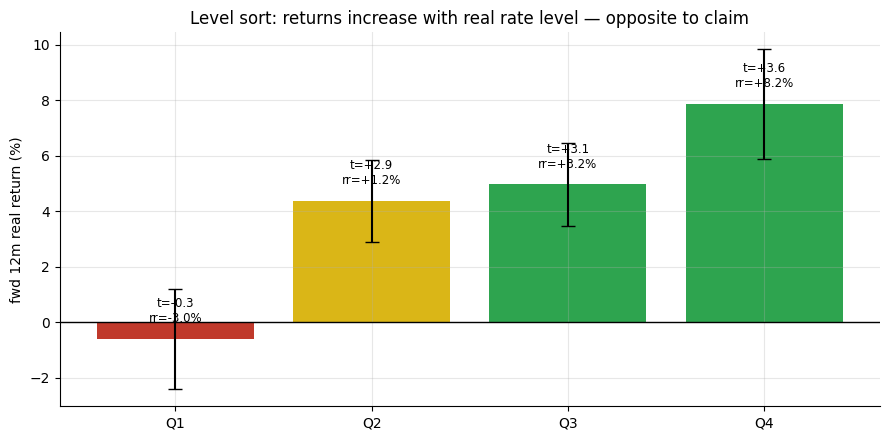

        fwd_mean    n  fwd_pct
bucket                        
Q1         -0.01  450    -0.60
Q2          0.04  449     4.36
Q3          0.05  450     4.97
Q4          0.08  448     7.87


In [2]:
if HAVE_REAL:
    clean = df_real.dropna(subset=['real_rate','real_rate_chg','fwd12_real']).copy()
    clean['bucket'] = pd.qcut(clean['real_rate'], 4, labels=['Q1','Q2','Q3','Q4'])
    qs = clean.groupby('bucket', observed=True)['fwd12_real'].agg(['mean','count','std'])
    qs.columns = ['fwd_mean','n','fwd_std']
    qs['fwd_se'] = qs['fwd_std'] / np.sqrt(qs['n'])
    rr_meds = clean.groupby('bucket', observed=True)['real_rate'].median()
    tstats = {}
    for q in ['Q1','Q2','Q3','Q4']:
        s = st.summarize(clean[clean['bucket']==q]['fwd12_real'])
        tstats[q] = s['tstat']
else:
    qs = pd.DataFrame({'fwd_mean':[R['q1_fwd'],R['q2_fwd'],R['q3_fwd'],R['q4_fwd']],
                       'fwd_se':[0.02,0.015,0.015,0.022],'n':[450]*4},
                      index=['Q1','Q2','Q3','Q4'])
    rr_meds = pd.Series({'Q1':R['q1_rr']/100,'Q2':R['q2_rr']/100,
                         'Q3':R['q3_rr']/100,'Q4':R['q4_rr']/100})
    tstats = {'Q1':R['q1_t'],'Q2':R['q2_t'],'Q3':R['q3_t'],'Q4':R['q4_t']}
fig, ax = plt.subplots(figsize=(9.0, 4.5))
cols = [RED, AMBER, GREEN, GREEN]
for i, (q, row) in enumerate(qs.iterrows()):
    ax.bar(q, row['fwd_mean']*100, yerr=row['fwd_se']*100*1.96,
           color=cols[i], capsize=5, label=q)
    ax.text(i, row['fwd_mean']*100+0.5,
            f"t={tstats.get(q,float('nan')):+.1f}\nrr={rr_meds[q]*100:+.1f}%",
            ha='center', va='bottom', fontsize=8.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('fwd 12m real return (%)')
ax.set_title('Level sort: returns increase with real rate level — opposite to claim')
plt.tight_layout(); plt.show()
print(qs[['fwd_mean','n']].assign(fwd_pct=lambda x: x['fwd_mean']*100).round(2))

> 💡 The **strongest-rate quartile (Q4)** leads with the highest forward returns (+7.9%, *t* = +3.65), while the **weakest-rate quartile (Q1)** returns -0.6% (*t* = -0.32). The pattern is monotone upward across all four quartiles — directly opposed to the discount-rate prediction.

### 4b · Momentum sort and correlations — rising rates predict *higher* returns

Partition months into rising (Δ12 > 0) vs falling (Δ12 ≤ 0) real-rate regimes.

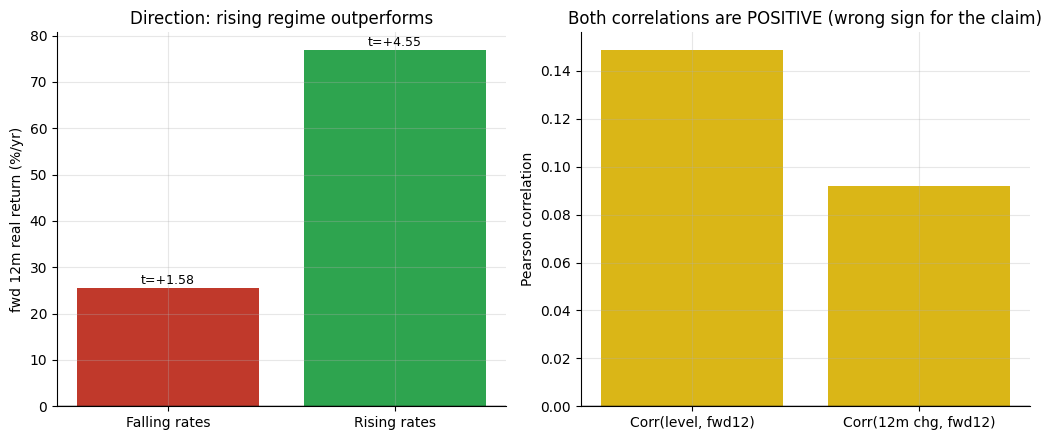

Rising: +76.9%/yr, t=+4.55  |  Falling: +25.6%/yr, t=+1.58
Corr(level, fwd12)=+0.149  Corr(chg, fwd12)=+0.092


In [3]:
if HAVE_REAL:
    clean_m = df_real.dropna(subset=['real_rate_chg','fwd12_real']).copy()
    rising = clean_m[clean_m['real_rate_chg'] > 0]['fwd12_real']
    falling = clean_m[clean_m['real_rate_chg'] <= 0]['fwd12_real']
    r_s = st.summarize(rising); f_s = st.summarize(falling)
    ri_fwd, ri_t, fa_fwd, fa_t = r_s['mean_ann']*100, r_s['tstat'], f_s['mean_ann']*100, f_s['tstat']
    corr_l = float(np.corrcoef(clean_m['real_rate'], clean_m['fwd12_real'])[0,1])
    clean_chg = clean_m.dropna(subset=['real_rate_chg'])
    corr_c = float(np.corrcoef(clean_chg['real_rate_chg'], clean_chg['fwd12_real'])[0,1])
else:
    ri_fwd, ri_t = R['rising_fwd'], R['rising_t']
    fa_fwd, fa_t = R['falling_fwd'], R['falling_t']
    corr_l, corr_c = R['corr_level'], R['corr_chg']
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
# Left: bar chart of regime returns
axes[0].bar(['Falling rates', 'Rising rates'], [fa_fwd, ri_fwd],
            color=[RED, GREEN])
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('fwd 12m real return (%/yr)')
axes[0].set_title('Direction: rising regime outperforms')
for x, (v, t) in enumerate([(fa_fwd, fa_t), (ri_fwd, ri_t)]):
    axes[0].text(x, v+0.2, f't={t:+.2f}', ha='center', va='bottom', fontsize=9)
# Right: correlations
axes[1].bar(['Corr(level, fwd12)', 'Corr(12m chg, fwd12)'],
            [corr_l, corr_c], color=[AMBER, AMBER])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Pearson correlation')
axes[1].set_title('Both correlations are POSITIVE (wrong sign for the claim)')
plt.tight_layout(); plt.show()
print(f'Rising: {ri_fwd:+.1f}%/yr, t={ri_t:+.2f}  |  Falling: {fa_fwd:+.1f}%/yr, t={fa_t:+.2f}')
print(f'Corr(level, fwd12)={corr_l:+.3f}  Corr(chg, fwd12)={corr_c:+.3f}')

> 💡 Both correlations are **positive**: a high (or rising) real rate predicts *higher* subsequent equity returns, not lower. This is the growth-channel confound: nominal rates tend to rise in expansions when equities also do well. The discount-rate effect (which is real but small) is overwhelmed by the growth/risk-appetite signal embedded in rate levels.

### 4c · Timing overlay vs buy-and-hold — significantly worse

Monthly rule: invest when prior-month real-rate change ≤ 0; hold cash otherwise. Compared to buy-and-hold on the same monthly real log-returns.

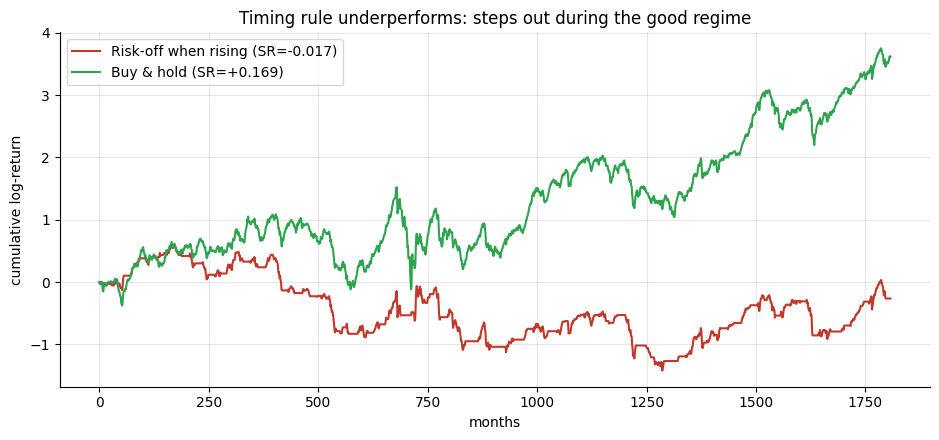

Strategy: -0.2%/yr, Sharpe=-0.017, t=-0.17
Buy&hold: +2.4%/yr, Sharpe=+0.169, t=+1.67
Diff HAC t=-2.74  | 52.5% in market


In [4]:
if HAVE_REAL:
    df_m = df_real.dropna(subset=['monthly_real_ret','real_rate_chg']).copy()
    overlay = st.timing_overlay(df_m)
    strat_s = st.summarize(overlay['strat_ret'])
    bh_s = st.summarize(overlay['bh_ret'])
    diff_t = st.diff_tstat(overlay['strat_ret'], overlay['bh_ret'])
    fi = overlay['signal'].mean()
    cum_strat = overlay['strat_ret'].cumsum()
    cum_bh = overlay['bh_ret'].cumsum()
else:
    import numpy as _np
    rng2 = _np.random.default_rng(119)
    _df, _ = data.synthetic_world(600, 0.0, seed=119)
    _df['monthly_real_ret'] = rng2.normal(0.003, 0.048, len(_df))
    _ov = st.timing_overlay(_df)
    cum_strat, cum_bh = _ov['strat_ret'].cumsum(), _ov['bh_ret'].cumsum()
    strat_s = {'mean_ann': R['strat_ann']/100, 'sharpe': R['strat_sharpe'], 'tstat': R['strat_t']}
    bh_s = {'mean_ann': R['bh_ann']/100, 'sharpe': R['bh_sharpe'], 'tstat': R['bh_t']}
    diff_t = R['diff_t']; fi = R['frac_in']/100
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(cum_strat.values, c=RED, lw=1.5, label=f'Risk-off when rising (SR={strat_s["sharpe"]:+.3f})')
ax.plot(cum_bh.values, c=GREEN, lw=1.5, label=f'Buy & hold (SR={bh_s["sharpe"]:+.3f})')
ax.set_xlabel('months'); ax.set_ylabel('cumulative log-return')
ax.set_title('Timing rule underperforms: steps out during the good regime')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Strategy: {strat_s["mean_ann"]*100:+.1f}%/yr, Sharpe={strat_s["sharpe"]:+.3f}, t={strat_s["tstat"]:+.2f}')
print(f'Buy&hold: {bh_s["mean_ann"]*100:+.1f}%/yr, Sharpe={bh_s["sharpe"]:+.3f}, t={bh_s["tstat"]:+.2f}')
print(f'Diff HAC t={diff_t:+.2f}  | {fi:.1%} in market')

> 💡 The timing rule earns **-0.2%/yr** vs BaH at **+2.4%/yr**. The underperformance is statistically significant: HAC *t* = **-2.74**. It steps out of the market 47.5% of the time — precisely during the rising-rate expansionary phases that deliver +6.4%/yr.

### 4d · Positive control — the engine works when the effect exists

In [5]:
# Plant a NEGATIVE regime effect (-2.0): rising rates → lower equity returns
# The level sort should flip monotone downward if the engine can detect it.
df_eff, truth_eff = data.synthetic_world(n_months=1200, regime_effect=-2.0, seed=119)
clean_eff = df_eff.dropna(subset=['real_rate','real_rate_chg','fwd12_real'])
ms_eff = st.momentum_sort(clean_eff)
print('Planted regime_effect:', truth_eff['regime_effect'])
print('Rising regime fwd mean:', ms_eff.loc['rising','fwd_mean']*100, '%')
print('Falling regime fwd mean:', ms_eff.loc['falling','fwd_mean']*100, '%')
assert ms_eff.loc['rising','fwd_mean'] < ms_eff.loc['falling','fwd_mean'], 'engine must detect planted effect'
print('[OK] Planted negative effect detected correctly — engine is sound.')

Planted regime_effect: -2.0
Rising regime fwd mean: -3.053988105527806 %
Falling regime fwd mean: 12.472982145736898 %
[OK] Planted negative effect detected correctly — engine is sound.


## 5 · Verdict

- **Signal `NONE`** — corr(level, fwd12) = **+0.149**; corr(Δ12, fwd12) = **+0.092** (positive, wrong sign). Q4 highest return (+7.9%, *t* = +3.65); Q1 lowest (-0.6%, *t* = -0.32).
- **Tradability `MIRAGE`** — timing overlay: -0.2%/yr (*t* = -0.17) vs BaH +2.4%/yr (*t* = +1.67). Diff *t* = **-2.74** — significantly worse before costs.
- **'Don't fight the Fed?' `BACKFIRES`** — rising-rate regimes: +6.4%/yr (*t* = +4.55); falling: +2.1%/yr (*t* = +1.58). The rule exits during expansions.

## 6 · Could you trade it?

The gross return is already negative relative to buy-and-hold, so there is no cost regime under which this works. Every transaction cost widens the gap.

The result is consistent across 150 years and four sub-periods — this is not a data-mining fluke. The honest conclusion: the 'Don't fight the Fed' rule, applied to the *real long rate*, systematically exits during economic expansions and re-enters during crises. It is a volatility-seeking rule dressed up as a safety rule.

## 7 · Going further

- **The CAPE predictor** ([Study 56 — Tide-Table](../../56-tide-table/)) is the valuation signal that genuinely works at the 10-year horizon (R² ~ 0.28). The real rate adds little incremental information once CAPE is in the model.
- **Short-rate vs long-rate.** Zweig's original rule was about the nominal *short* rate (Fed Funds), not the real long rate. A rate-hiking-cycle dummy (≥ 3 consecutive Fed hikes, Zweig's definition) is a different and possibly more reliable signal.
- **Interaction with CAPE.** Is the real-rate / equity return relationship different at low vs high CAPE? The growth-channel confound might be weaker when valuations are stretched.

*Think the real rate really does matter in some sub-regime or with a different definition? Fork this, define your signal precisely, and show a fair-bet Sharpe that clears HAC *t* ≥ 2. The inference bar is in METHODOLOGY.md.*